# Detecção de fraudes em cartões de crédito

## Um experimento reproduzível para classes extremamente desbalanceadas

Este notebook percorre o ciclo completo de um problema de fraude: carregamento da base pública, validação, análise exploratória, separação estratificada, treinamento, escolha de limiar em validação e avaliação final fora da amostra.

**Objetivo de negócio:** detectar o maior número possível de fraudes sem gerar uma quantidade impraticável de alertas falsos. Por isso, acurácia não é usada como critério principal.

> Projeto educacional. A regra de custo é ilustrativa e precisa ser calibrada com dados reais de perdas e operação antes de qualquer uso produtivo.


## 1. Estratégia do experimento

- **Fonte:** Credit Card Fraud Detection, disponibilizada publicamente pelo tutorial do TensorFlow.
- **Variáveis:** `Time`, `Amount`, `Class` e `V1` a `V28`, transformadas por PCA na base original.
- **Partição:** 60% treino, 20% validação e 20% teste, sempre com `stratify`.
- **Modelos:** Regressão Logística e Random Forest com pesos de classe.
- **Seleção:** o limiar e o modelo são escolhidos somente na validação.
- **Teste:** utilizado uma única vez para estimar desempenho fora da amostra.
- **Custo relativo:** falso negativo = 25 e falso positivo = 1.

A curva Precision–Recall recebe destaque porque é especialmente informativa em classificação muito desbalanceada.


In [1]:
from __future__ import annotations

import os
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

RANDOM_STATE = 42
FALSE_NEGATIVE_COST = 25
FALSE_POSITIVE_COST = 1
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
IMAGE_DIR = ROOT / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
print("Ambiente configurado com sucesso.")


Ambiente configurado com sucesso.


## 2. Carregamento e validação

O CSV não é versionado no GitHub. A execução normal baixa os dados pelo link público. A variável de ambiente `CREDITCARD_DATA_PATH` existe apenas para permitir validação local sem repetir o download.


In [2]:
local_data_path = os.getenv("CREDITCARD_DATA_PATH")
if local_data_path and Path(local_data_path).exists():
    raw = pd.read_csv(local_data_path)
    source_label = "cache local da mesma base pública"
else:
    raw = pd.read_csv(DATA_URL)
    source_label = DATA_URL

expected_columns = {"Time", "Amount", "Class", *[f"V{i}" for i in range(1, 29)]}
missing_columns = sorted(expected_columns.difference(raw.columns))
if missing_columns:
    raise ValueError(f"Colunas esperadas não encontradas: {missing_columns}")

print(f"Fonte: {source_label}")
print(f"Dimensão original: {raw.shape[0]:,} linhas × {raw.shape[1]} colunas")
print(f"Valores ausentes: {raw.isna().sum().sum():,}")
print(f"Duplicatas exatas: {raw.duplicated().sum():,}")


Fonte: cache local da mesma base pública
Dimensão original: 284,807 linhas × 31 colunas
Valores ausentes: 0
Duplicatas exatas: 1,081


In [3]:
data = raw.drop_duplicates().reset_index(drop=True)
class_summary = (
    data["Class"].value_counts().sort_index()
    .rename(index={0: "Normal", 1: "Fraude"})
    .to_frame("quantidade")
)
class_summary["percentual"] = class_summary["quantidade"] / len(data) * 100

print(f"Linhas após remover duplicatas: {len(data):,}")
class_summary


Linhas após remover duplicatas: 283,726


        quantidade  percentual
Normal      283253   99.833290
Fraude         473    0.166710

### Por que a acurácia engana?

Após a limpeza, somente **0.1667%** das transações são fraudes. Um classificador que sempre respondesse “normal” teria aproximadamente **99.8333% de acurácia**, mas recall de fraude igual a zero.

Por isso, o projeto acompanha precisão, recall, F1, ROC-AUC, PR-AUC, matriz de confusão e custo relativo.


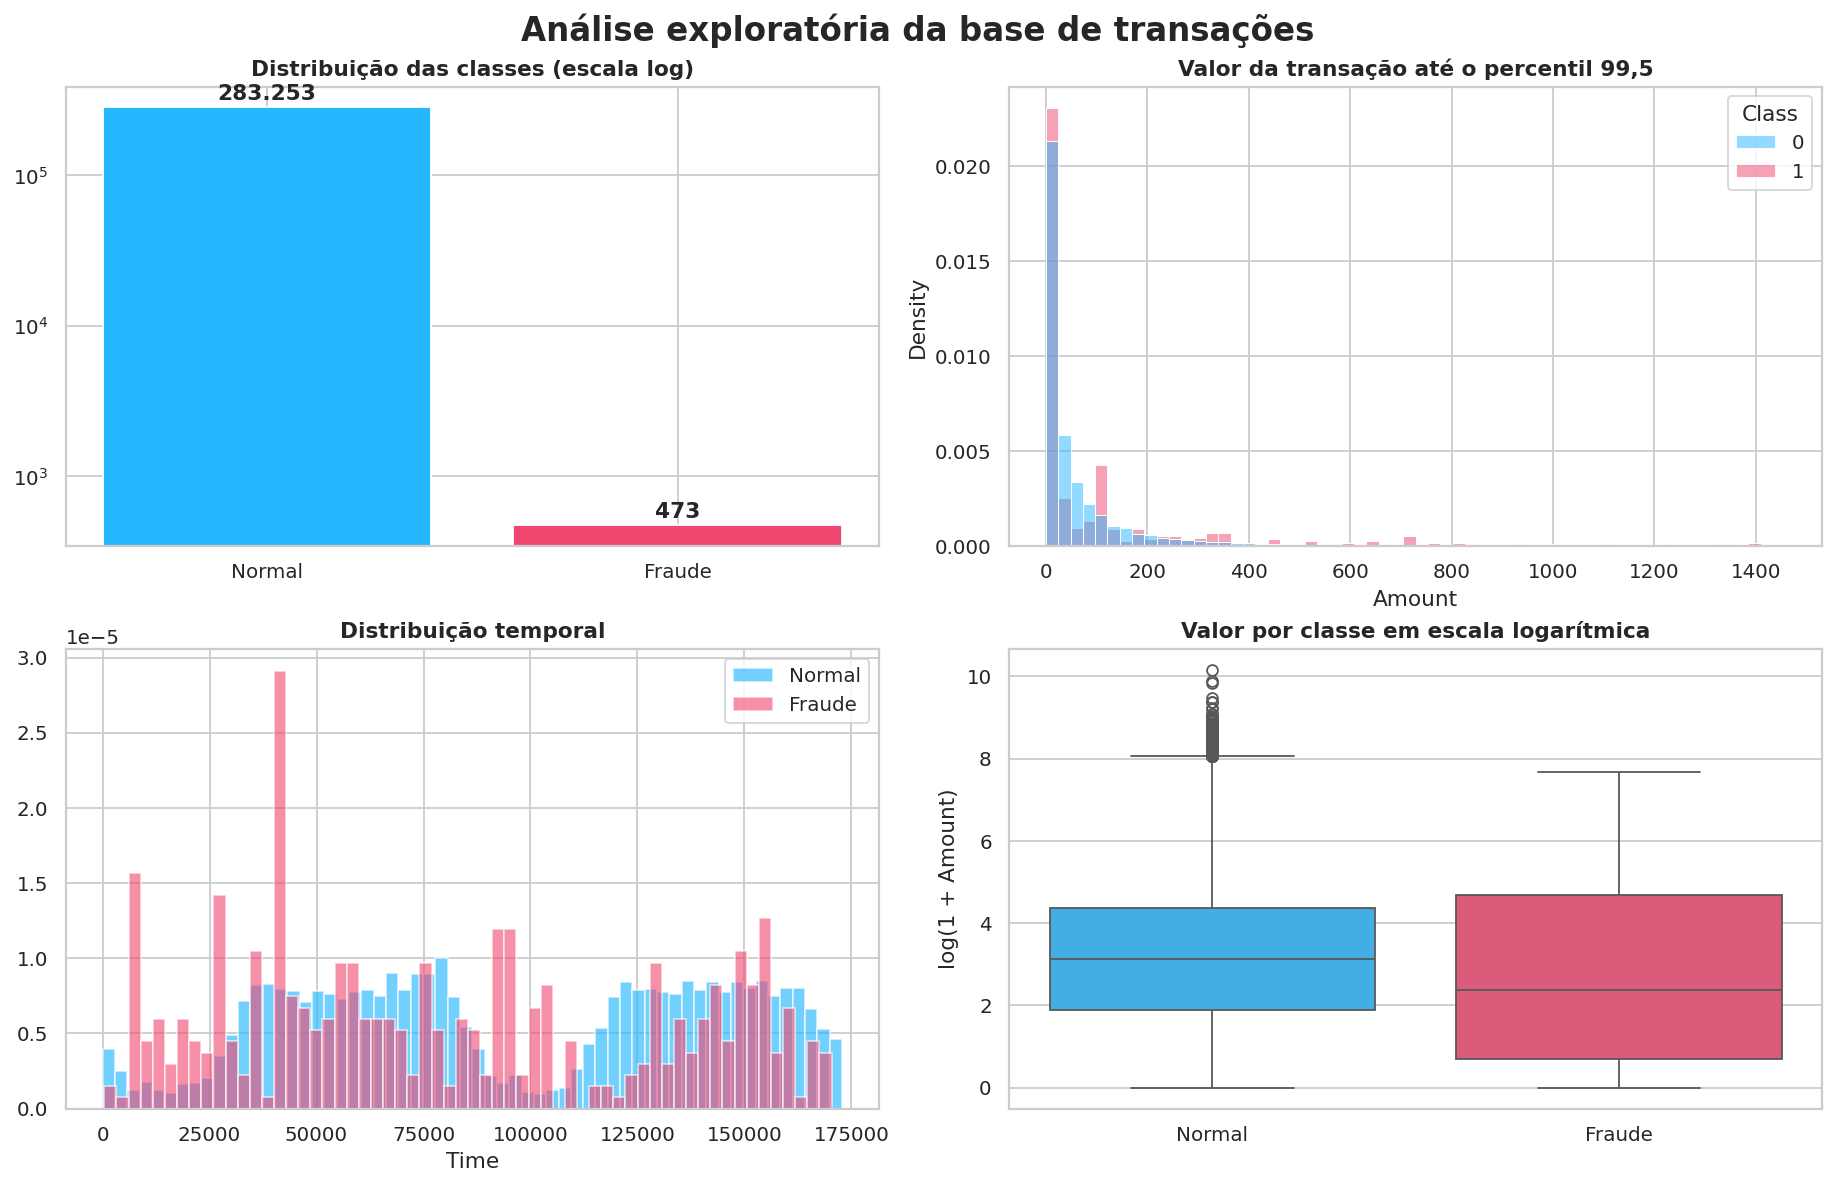

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
class_counts = data["Class"].value_counts().sort_index()
axes[0, 0].bar(["Normal", "Fraude"], class_counts.values, color=["#27b7ff", "#ef476f"])
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Distribuição das classes (escala log)", weight="bold")

amount_limit = data["Amount"].quantile(0.995)
sns.histplot(data=data[data["Amount"] <= amount_limit], x="Amount", hue="Class", bins=60,
             stat="density", common_norm=False, palette={0: "#27b7ff", 1: "#ef476f"}, ax=axes[0, 1])
axes[0, 1].set_title("Valor até o percentil 99,5", weight="bold")

normal_time = data.loc[data["Class"] == 0, "Time"].sample(20000, random_state=RANDOM_STATE)
fraud_time = data.loc[data["Class"] == 1, "Time"]
axes[1, 0].hist(normal_time, bins=60, density=True, alpha=0.65, color="#27b7ff", label="Normal")
axes[1, 0].hist(fraud_time, bins=60, density=True, alpha=0.60, color="#ef476f", label="Fraude")
axes[1, 0].set_title("Distribuição temporal", weight="bold")
axes[1, 0].legend()

box_data = data[["Class", "Amount"]].copy()
box_data["log1p_Amount"] = np.log1p(box_data["Amount"])
sns.boxplot(data=box_data, x="Class", y="log1p_Amount", hue="Class",
            palette={0: "#27b7ff", 1: "#ef476f"}, legend=False, ax=axes[1, 1])
axes[1, 1].set_xticks([0, 1], ["Normal", "Fraude"])
axes[1, 1].set_title("Valor por classe em escala log", weight="bold")
axes[1, 1].set_ylabel("log(1 + Amount)")
plt.show()


## 3. Separação sem vazamento

O teste permanece isolado. Transformações são ajustadas dentro do pipeline usando apenas o treino. O limiar de decisão é escolhido na validação, nunca no teste.


In [5]:
X = data.drop(columns="Class")
y = data["Class"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "partição": ["treino", "validação", "teste"],
    "linhas": [len(y_train), len(y_valid), len(y_test)],
    "fraudes": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "taxa_fraude": [y_train.mean(), y_valid.mean(), y_test.mean()],
})
split_summary


     partição  linhas  fraudes  taxa_fraude
0      treino  170235      284     0.001668
1   validação   56745       94     0.001657
2       teste   56746       95     0.001674

In [6]:
preprocessor = ColumnTransformer(
    [("robust", RobustScaler(), ["Time", "Amount"])],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

models = {
    "Regressão Logística": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced", solver="liblinear",
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=120, max_depth=12, min_samples_leaf=2,
        max_features="sqrt", class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
}

fit_times = {}
for name, model in models.items():
    started = time.perf_counter()
    model.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - started
    print(f"{name}: {fit_times[name]:.1f}s")


Regressão Logística: 2.1s
Random Forest: 11.6s


## 4. Escolha do limiar com custo relativo

O limiar padrão `0.5` não representa automaticamente a melhor decisão. Aqui, uma fraude não detectada recebe custo relativo 25 e um falso alerta recebe custo 1. Esses pesos são apenas uma hipótese educacional.


In [7]:
def select_threshold(y_true, probabilities, fn_cost=25, fp_cost=1):
    quantiles = np.quantile(probabilities, np.linspace(0.75, 0.9999, 250))
    candidates = np.unique(np.concatenate([np.linspace(0.01, 0.99, 197), quantiles]))
    rows = []
    for threshold in candidates:
        prediction = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
        rows.append({
            "threshold": threshold, "cost": fp_cost * fp + fn_cost * fn,
            "precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "f1": f1_score(y_true, prediction, zero_division=0),
            "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        })
    return pd.DataFrame(rows).sort_values(["cost", "recall", "precision"], ascending=[True, False, False]).iloc[0]

validation_rows = []
thresholds = {}
for name, model in models.items():
    probabilities = model.predict_proba(X_valid)[:, 1]
    selected = select_threshold(y_valid, probabilities, FALSE_NEGATIVE_COST, FALSE_POSITIVE_COST)
    selected["model"] = name
    selected["roc_auc"] = roc_auc_score(y_valid, probabilities)
    selected["pr_auc"] = average_precision_score(y_valid, probabilities)
    validation_rows.append(selected)
    thresholds[name] = float(selected["threshold"])

validation_df = pd.DataFrame(validation_rows).sort_values(["cost", "pr_auc"], ascending=[True, False]).reset_index(drop=True)
champion = validation_df.loc[0, "model"]
validation_df[["model", "threshold", "precision", "recall", "f1", "roc_auc", "pr_auc", "cost"]].round(4)


                   model  threshold  precision  recall      f1  roc_auc  pr_auc  cost
0          Random Forest      0.2500     0.7426  0.7979  0.7692   0.9553  0.7872   501
1  Regressão Logística      0.9750     0.4808  0.7979  0.6000   0.9712  0.6922   556

## 5. Avaliação final no teste

Os limiares abaixo foram congelados antes de consultar o teste. Isso evita escolher uma política que apenas parece boa na amostra final.


In [8]:
test_rows = []
test_probabilities = {}
test_predictions = {}

for name, model in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    prediction = (probabilities >= thresholds[name]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, prediction, labels=[0, 1]).ravel()
    test_probabilities[name] = probabilities
    test_predictions[name] = prediction
    test_rows.append({
        "model": name, "threshold": thresholds[name],
        "precision": precision_score(y_test, prediction, zero_division=0),
        "recall": recall_score(y_test, prediction, zero_division=0),
        "f1": f1_score(y_test, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
        "pr_auc": average_precision_score(y_test, probabilities),
        "accuracy": (prediction == y_test.to_numpy()).mean(),
        "cost": FALSE_POSITIVE_COST * fp + FALSE_NEGATIVE_COST * fn,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    })

model_order = {name: index for index, name in enumerate(validation_df["model"])}
test_df = pd.DataFrame(test_rows).sort_values("model", key=lambda values: values.map(model_order)).reset_index(drop=True)
test_df.round(4)


                   model  threshold  precision  recall      f1  roc_auc  pr_auc  accuracy  cost     tn  fp  fn  tp
0          Random Forest      0.2500     0.7476  0.8105  0.7778   0.9775  0.8400    0.9992   476  56625  26  18  77
1  Regressão Logística      0.9750     0.5226  0.8526  0.6480   0.9670  0.7307    0.9984   424  56577  74  14  81


Random Forest
              precision    recall  f1-score   support

      Normal     0.9997    0.9995    0.9996     56651
      Fraude     0.7476    0.8105    0.7778        95

    accuracy                         0.9992     56746
   macro avg     0.8736    0.9050    0.8887     56746
weighted avg     0.9993    0.9992    0.9992     56746

Regressão Logística
              precision    recall  f1-score   support

      Normal     0.9998    0.9987    0.9992     56651
      Fraude     0.5226    0.8526    0.6480        95

    accuracy                         0.9984     56746
   macro avg     0.7612    0.9257    0.8236     56746
weighted avg     0.9990    0.9984    0.9986     56746


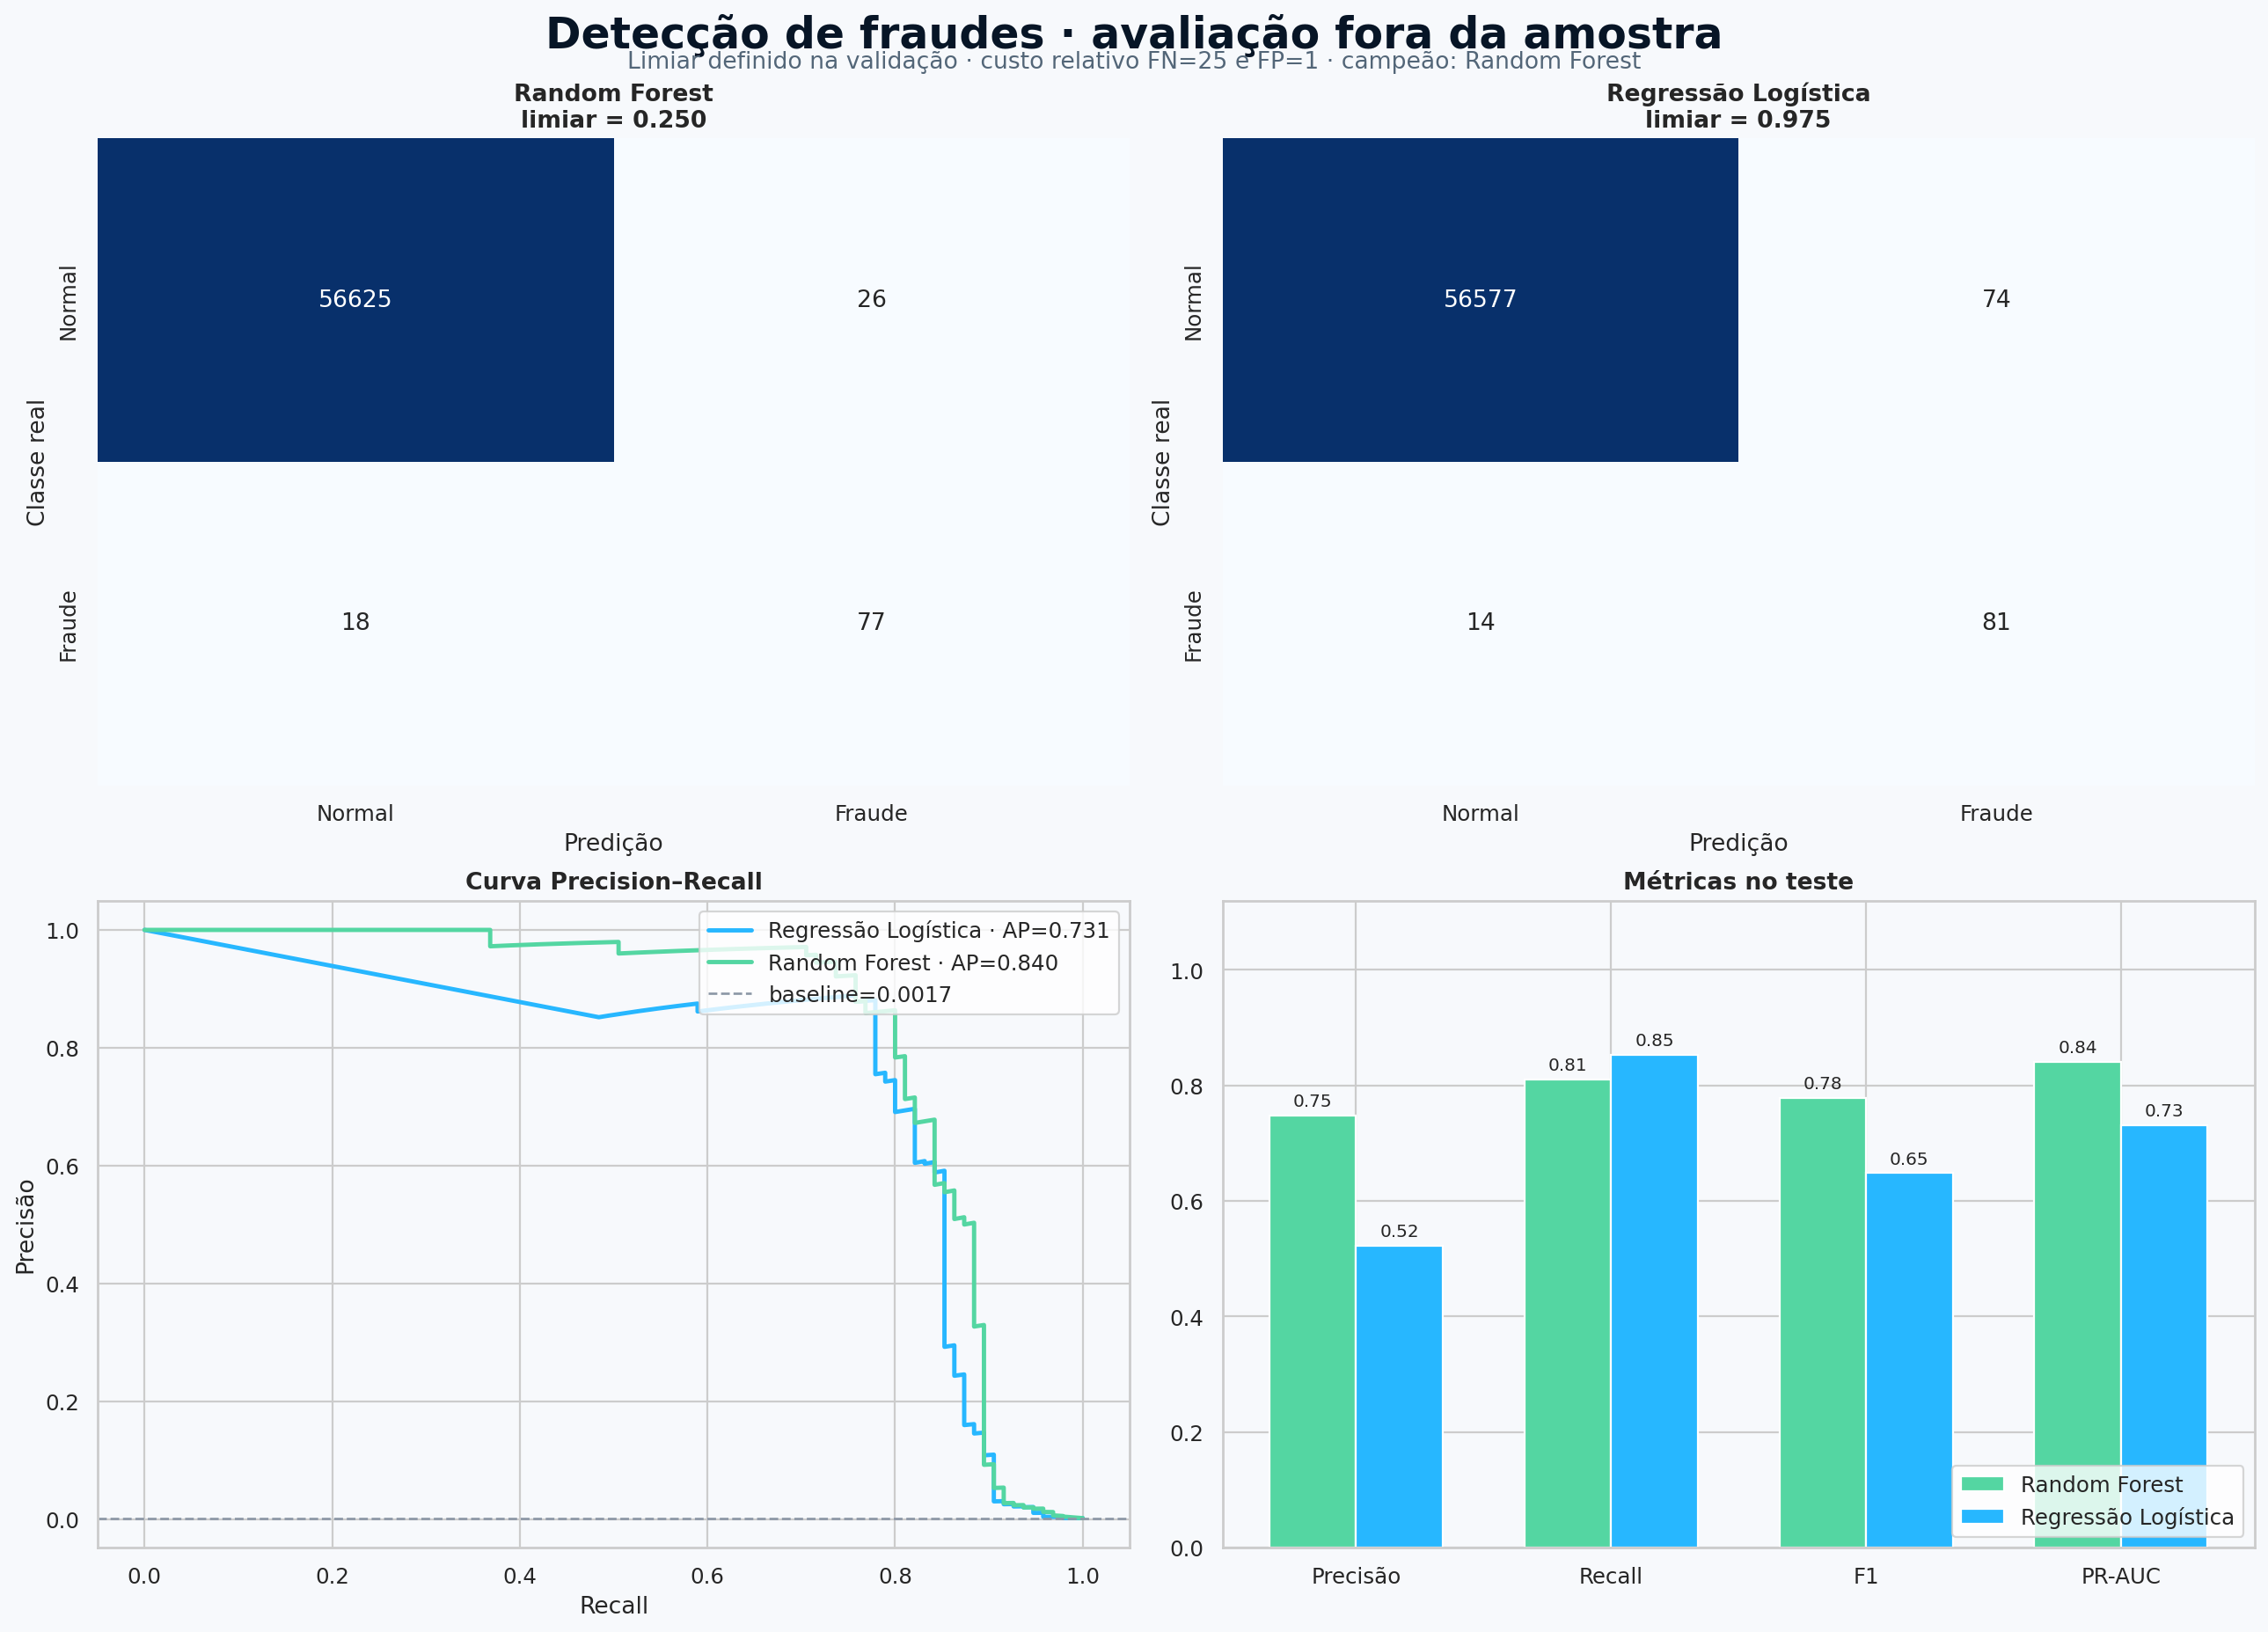

In [9]:
colors = {"Regressão Logística": "#27b7ff", "Random Forest": "#54d6a2"}
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
fig.patch.set_facecolor("#f7f9fc")
for axis in axes.flat:
    axis.set_facecolor("#f7f9fc")

for axis, row in zip(axes[0], test_rows):
    matrix = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis,
                xticklabels=["Normal", "Fraude"], yticklabels=["Normal", "Fraude"])
    axis.set_title(f'{row["model"]} · limiar={row["threshold"]:.3f}', weight="bold")
    axis.set_xlabel("Predição")
    axis.set_ylabel("Classe real")

for name, probabilities in test_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    ap = average_precision_score(y_test, probabilities)
    axes[1, 0].plot(recall, precision, color=colors[name], lw=2.2, label=f"{name} · AP={ap:.3f}")
axes[1, 0].axhline(y_test.mean(), color="#8c97a6", ls="--", label=f"baseline={y_test.mean():.4f}")
axes[1, 0].set(title="Curva Precision–Recall", xlabel="Recall", ylabel="Precisão")
axes[1, 0].legend()

metric_names = ["precision", "recall", "f1", "pr_auc"]
labels = ["Precisão", "Recall", "F1", "PR-AUC"]
x = np.arange(len(metric_names)); width = 0.34
for index, row in enumerate(test_rows):
    values = [row[metric] for metric in metric_names]
    bars = axes[1, 1].bar(x + (index - 0.5) * width, values, width, color=colors[row["model"]], label=row["model"])
    axes[1, 1].bar_label(bars, fmt="%.2f", padding=3)
axes[1, 1].set_xticks(x, labels)
axes[1, 1].set_ylim(0, 1.12)
axes[1, 1].set_title("Métricas no teste", weight="bold")
axes[1, 1].legend(loc="lower right")

fig.suptitle("Detecção de fraudes · avaliação fora da amostra", color="#071526", fontsize=22, fontweight="bold", y=1.02)
output_path = IMAGE_DIR / "model-comparison.png"
fig.savefig(output_path, dpi=160, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()


## 6. Interpretação dos resultados

O **Random Forest** foi selecionado na validação: custo relativo **501**, contra **556** da Regressão Logística, e PR-AUC superior. No teste, atingiu:

- precisão: **74.76%**;
- recall: **81.05%**;
- F1: **0.778**;
- PR-AUC: **0.840**;
- 77 fraudes detectadas, 18 não detectadas e 26 alertas falsos.

A Regressão Logística apresentou recall maior, **85.26%**, mas gerou 74 falsos positivos. Curiosamente, seu custo observado no teste foi menor sob a razão ilustrativa 25:1. Isso não autoriza trocar o modelo depois de consultar o teste; mostra que a decisão é sensível ao custo adotado e à variação amostral.

Para produção, o próximo passo seria validar os custos reais, calibrar probabilidades, testar por janela temporal e acompanhar drift. O conjunto de teste deve permanecer como estimativa final, não como ferramenta de ajuste.


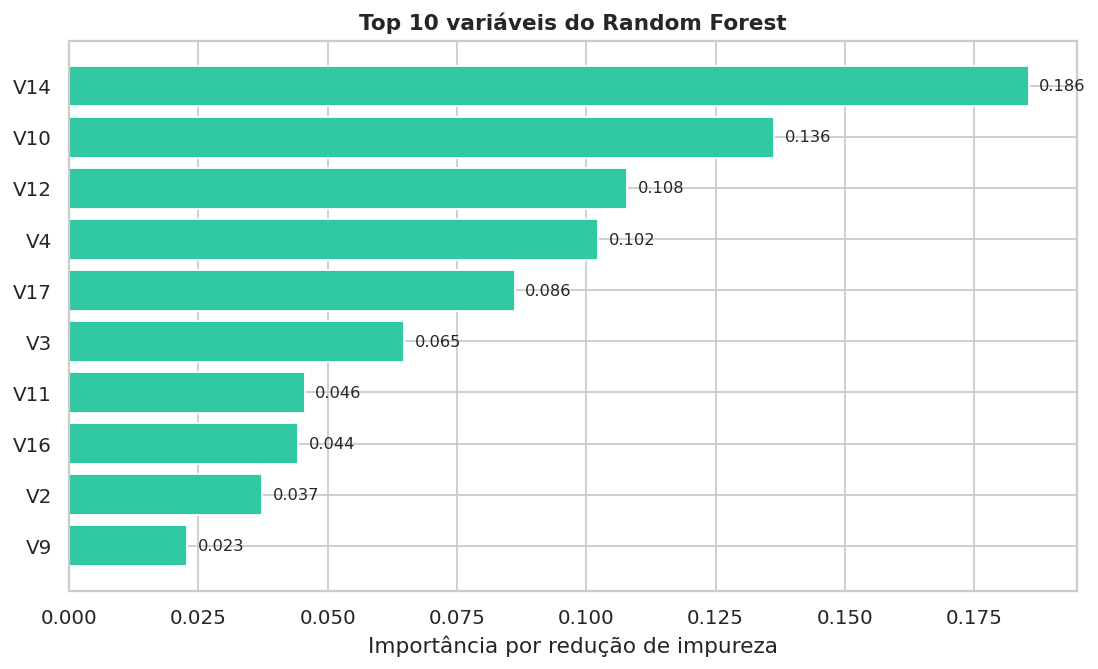

In [10]:
forest_importance = pd.Series(
    models["Random Forest"].feature_importances_, index=X.columns
).nlargest(10).sort_values()

fig, axis = plt.subplots(figsize=(10, 5.5))
axis.barh(forest_importance.index, forest_importance.values, color="#31c9a4")
axis.set_title("Top 10 variáveis do Random Forest", weight="bold")
axis.set_xlabel("Importância por redução de impureza")
plt.show()


### Cuidado com a importância das variáveis

A importância do Random Forest indica contribuição para as divisões das árvores, não causalidade. As variáveis `V1` a `V28` foram anonimizadas por PCA, o que limita interpretação de negócio. Uma solução real deve combinar explicabilidade local, validação de estabilidade e conhecimento do processo antifraude.


## 7. Limitações e próximos passos

- O split estratificado aleatório é adequado ao exercício, mas uma validação temporal representaria melhor a implantação futura.
- Os pesos de custo são ilustrativos; perdas reais variam por valor, cliente, canal e política operacional.
- A base contém transações de um período específico e pode não representar outros mercados.
- Remover duplicatas reduz risco de vazamento entre partições, mas a decisão deve ser validada com a origem dos dados.
- Class weights foram utilizados para lidar com o desbalanceamento sem criar observações sintéticas.
- Uma evolução pode comparar undersampling, oversampling e modelos de boosting, sempre mantendo o teste isolado.
- Monitoramento de drift, calibração e revisão humana dos alertas são requisitos para uma aplicação responsável.


In [11]:
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Random state: {RANDOM_STATE}")


Python: 3.x
pandas: 2.2.3
NumPy: 2.3.5
scikit-learn: 1.8.0
Random state: 42


## Referências

- [TensorFlow — Classification on imbalanced data](https://www.tensorflow.org/tutorials/structured_data/imbalanced_data)
- [scikit-learn — Precision–Recall](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html)
- [scikit-learn — RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [scikit-learn — LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [scikit-learn — Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)

---

**Conclusão:** em fraude, escolher a métrica e o limiar é parte do modelo. O melhor classificador não é necessariamente o de maior acurácia, mas o que produz uma decisão operacional sustentável e validada fora da amostra.
